In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
cd /content/drive/MyDrive/Savio

/content/drive/MyDrive/Savio


In [3]:
'''
Value Count Label_multi
0     1672837
4      231073
9      158930
2      128027
3       10293
6        5796
5        5499
1        1966
8          36
7          11
10          1

'''

df = pd.read_csv('engineered_features.csv')
top_3_labels = df['Label_multi'].value_counts().nlargest(3)
top_3_label_values = df['Label_multi'].value_counts().nlargest(3).index
df = df[df['Label_multi'].isin(top_3_label_values)]
label_mapping = {0: 0, 4: 1, 9: 2}
df['Label_multi'] = df['Label_multi'].map(label_mapping)

In [4]:
df['Label_multi'].value_counts()

,count
Label_multi,
0,1672837
1,231073
2,158930


In [5]:
df = df.drop(columns=['flow_duration_bin','packet_count_bin'])

In [6]:
df = df.fillna(0)

In [7]:
df.head()

,packet_count_ratio,byte_volume_ratio,byte_volume_diff,forward_dominant,backward_dominant,balanced_traffic,bytes_per_second,packets_per_second,iat_forward_backward_ratio,total_iat_variation,fwd_iat_variation,bwd_iat_variation,is_bursty,burstiness_score,iat_consistency,fwd_bwd_iat_similarity,syn_only,syn_ack,fin_only,rst_present,flag_density,syn_ack_ratio,fin_ack_ratio,urgent_flag_present,push_flag_present,urgent_push_combo,is_short_flow,is_medium_flow,is_long_flow,low_packet_count,medium_packet_count,high_packet_count,incomplete_session,abnormal_termination,normal_termination,zero_window_forward,zero_window_backward,zero_window_any,large_window_forward,large_window_backward,large_window_any,negative_window,header_length_ratio,total_header_length,header_length_diff,header_length_match,header_length_discrepancy,has_bulk_transfer,bulk_transfer_size,bulk_transfer_rate,bulk_direction_ratio,bulk_packet_ratio,segment_size_ratio,segment_size_diff,total_segment_size,calculated_avg_packet_size,avg_packet_size_diff,subflow_packet_ratio,subflow_byte_ratio,subflow_fwd_packet_ratio,subflow_bwd_packet_ratio,data_packet_ratio,has_data_packets,min_segment_size_anomaly,segment_size_consistency,activity_ratio,activity_variation,idle_variation,high_activity,low_activity,long_idle,short_idle,activity_range,idle_range,activity_idle_ratio,active_idle_correlation,fwd_bwd_packet_rate_ratio,fwd_bwd_byte_rate_ratio,high_flow_rate,low_flow_rate,high_byte_rate,low_byte_rate,packet_rate_consistency,byte_rate_consistency,timing_anomaly_score,traffic_pattern_risk,ddos_indicator,data_exfiltration_indicator,size_rate_interaction,duration_packet_interaction,duration_byte_interaction,syn_packet_ratio,ack_packet_ratio,fin_packet_ratio,iat_size_ratio,duration_size_ratio,subflow_main_packet_ratio,subflow_main_byte_ratio,log_flow_duration,log_total_fwd_packets,log_total_bwd_packets,log_total_fwd_bytes,log_total_bwd_bytes,log_flow_bytes_s,log_flow_packets_s,sqrt_flow_duration,sqrt_total_packets,reciprocal_flow_duration,reciprocal_packet_count,zscore_Flow_Duration,zscore_Total_Fwd_Packets,zscore_Total_Length_of_Fwd_Packets,zscore_Flow_Bytes_s,zscore_Flow_Packets_s,flow_duration_bin_numeric,packet_count_bin_numeric,Label_multi
0,2.0,12.000000,12.0,0,0,1,3.000000,0.500000,3.0,0.0,0.0,0.0,0,-0.750000,0.0,1.2,0,0,0,0,0.333333,0.0,0.0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,40.000000,40.0,40.0,1,0.0,0,0.0,0.0,0.0,0.0,6.000000,6.0,6.0,4.0,5.0,2.0,12.000000,0.666667,0.0,0.333333,1,0,2.857143,0.0,0.0,0.0,0,0,0,1,0.0,0.0,0.0,0,666666.666700,2.500000,0,0,1,0,0.999999,9.999998e-07,0.0,0.2,0,0,4.000000e+06,6.0,36.0,0.0,0.333333,0.0,0.428571,0.230769,0.666667,0.923077,1.386294,1.098612,0.000000,2.564949,0.00000,15.201805,13.410047,2.000000,1.732051,0.250000,0.333333,-0.457416,-0.009374,-0.050059,0.0,0.0,1.0,1.0,0
1,0.5,0.857143,0.0,0,0,1,0.109091,0.018182,0.0,0.0,0.0,0.0,0,-0.990909,0.0,0.0,0,0,0,0,0.666667,0.0,0.0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.952381,40.0,0.0,1,0.0,0,0.0,0.0,0.0,0.0,0.857143,0.0,12.0,4.0,5.0,0.5,0.857143,0.500000,0.5,0.000000,0,0,2.857143,0.0,0.0,0.0,0,0,0,1,0.0,0.0,0.0,0,0.999891,0.513393,0,0,0,0,0.499973,4.999955e-07,0.0,0.0,0,0,5.504587e+04,109.0,1308.0,0.0,0.500000,0.0,0.000000,8.384615,0.666667,0.923077,4.700480,0.693147,0.693147,1.945910,1.94591,11.609078,9.817364,10.488088,1.732051,0.009091,0.333333,-0.457413,-0.010833,-0.050615,0.0,0.0,2.0,1.0,0
2,0.5,0.857143,0.0,0,0,1,0.226415,0.037736,0.0,0.0,0.0,0.0,0,-0.981132,0.0,0.0,0,0,0,0,0.666667,0.0,0.0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.952381,40.0,0.0,1,0.0,0,0.0,0.0,0.0,0.0,0.857143,0.0,12.0,4.0,5.0,0.5,0.857143,0.500000,0.5,0.000000,0,0,2.857143,0.0,0.0,0.0,0,0,0,1,0.0,0.0,0.0,0,0.999948,0.527273,0,0,0,0,0.499987,4.999978e-07,0.0,0.0,0,0,1.153846e+05,52.0,624.0,0.0,0.500000,0.0,0.000000,4.000000,0.666667,0.923077,3.970292,0.693147,0.693147,1.945910,1.94591,12.349178,10.557440,7.280110,1.732051,0.018868,0.333333,-0.457415,-0.010833,-0.050615,0.0,0.0,1.0,1.0,0
3,0.5,0.857143,0.0,0,0,1,0.342857,0.

In [8]:
df = df.apply(pd.to_numeric, errors="coerce")

In [9]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [10]:
df = df.round(2)

In [11]:
df.head()

,packet_count_ratio,byte_volume_ratio,byte_volume_diff,forward_dominant,backward_dominant,balanced_traffic,bytes_per_second,packets_per_second,iat_forward_backward_ratio,total_iat_variation,fwd_iat_variation,bwd_iat_variation,is_bursty,burstiness_score,iat_consistency,fwd_bwd_iat_similarity,syn_only,syn_ack,fin_only,rst_present,flag_density,syn_ack_ratio,fin_ack_ratio,urgent_flag_present,push_flag_present,urgent_push_combo,is_short_flow,is_medium_flow,is_long_flow,low_packet_count,medium_packet_count,high_packet_count,incomplete_session,abnormal_termination,normal_termination,zero_window_forward,zero_window_backward,zero_window_any,large_window_forward,large_window_backward,large_window_any,negative_window,header_length_ratio,total_header_length,header_length_diff,header_length_match,header_length_discrepancy,has_bulk_transfer,bulk_transfer_size,bulk_transfer_rate,bulk_direction_ratio,bulk_packet_ratio,segment_size_ratio,segment_size_diff,total_segment_size,calculated_avg_packet_size,avg_packet_size_diff,subflow_packet_ratio,subflow_byte_ratio,subflow_fwd_packet_ratio,subflow_bwd_packet_ratio,data_packet_ratio,has_data_packets,min_segment_size_anomaly,segment_size_consistency,activity_ratio,activity_variation,idle_variation,high_activity,low_activity,long_idle,short_idle,activity_range,idle_range,activity_idle_ratio,active_idle_correlation,fwd_bwd_packet_rate_ratio,fwd_bwd_byte_rate_ratio,high_flow_rate,low_flow_rate,high_byte_rate,low_byte_rate,packet_rate_consistency,byte_rate_consistency,timing_anomaly_score,traffic_pattern_risk,ddos_indicator,data_exfiltration_indicator,size_rate_interaction,duration_packet_interaction,duration_byte_interaction,syn_packet_ratio,ack_packet_ratio,fin_packet_ratio,iat_size_ratio,duration_size_ratio,subflow_main_packet_ratio,subflow_main_byte_ratio,log_flow_duration,log_total_fwd_packets,log_total_bwd_packets,log_total_fwd_bytes,log_total_bwd_bytes,log_flow_bytes_s,log_flow_packets_s,sqrt_flow_duration,sqrt_total_packets,reciprocal_flow_duration,reciprocal_packet_count,zscore_Flow_Duration,zscore_Total_Fwd_Packets,zscore_Total_Length_of_Fwd_Packets,zscore_Flow_Bytes_s,zscore_Flow_Packets_s,flow_duration_bin_numeric,packet_count_bin_numeric,Label_multi
0,2.0,12.00,12.0,0,0,1,3.00,0.50,3.0,0.0,0.0,0.0,0,-0.75,0.0,1.2,0,0,0,0,0.33,0.0,0.0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,40.00,40.0,40.0,1,0.0,0,0.0,0.0,0.0,0.0,6.00,6.0,6.0,4.0,5.0,2.0,12.00,0.67,0.0,0.33,1,0,2.86,0.0,0.0,0.0,0,0,0,1,0.0,0.0,0.0,0,666666.67,2.50,0,0,1,0,1.0,0.0,0.0,0.2,0,0,4000000.00,6.0,36.0,0.0,0.33,0.0,0.43,0.23,0.67,0.92,1.39,1.10,0.00,2.56,0.00,15.20,13.41,2.00,1.73,0.25,0.33,-0.46,-0.01,-0.05,0.0,0.0,1.0,1.0,0
1,0.5,0.86,0.0,0,0,1,0.11,0.02,0.0,0.0,0.0,0.0,0,-0.99,0.0,0.0,0,0,0,0,0.67,0.0,0.0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.95,40.0,0.0,1,0.0,0,0.0,0.0,0.0,0.0,0.86,0.0,12.0,4.0,5.0,0.5,0.86,0.50,0.5,0.00,0,0,2.86,0.0,0.0,0.0,0,0,0,1,0.0,0.0,0.0,0,1.00,0.51,0,0,0,0,0.5,0.0,0.0,0.0,0,0,55045.87,109.0,1308.0,0.0,0.50,0.0,0.00,8.38,0.67,0.92,4.70,0.69,0.69,1.95,1.95,11.61,9.82,10.49,1.73,0.01,0.33,-0.46,-0.01,-0.05,0.0,0.0,2.0,1.0,0
2,0.5,0.86,0.0,0,0,1,0.23,0.04,0.0,0.0,0.0,0.0,0,-0.98,0.0,0.0,0,0,0,0,0.67,0.0,0.0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.95,40.0,0.0,1,0.0,0,0.0,0.0,0.0,0.0,0.86,0.0,12.0,4.0,5.0,0.5,0.86,0.50,0.5,0.00,0,0,2.86,0.0,0.0,0.0,0,0,0,1,0.0,0.0,0.0,0,1.00,0.53,0,0,0,0,0.5,0.0,0.0,0.0,0,0,115384.62,52.0,624.0,0.0,0.50,0.0,0.00,4.00,0.67,0.92,3.97,0.69,0.69,1.95,1.95,12.35,10.56,7.28,1.73,0.02,0.33,-0.46,-0.01,-0.05,0.0,0.0,1.0,1.0,0
3,0.5,0.86,0.0,0,0,1,0.34,0.06,0.0,0.0,0.0,0.0,0,-0.97,0.0,0.0,0,0,0,0,0.67,0.0,0.0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.95,40.0,0.0,1,0.0,0,0.0,0.0,0.0,0.0,0.86,0.0,12.0,4.0,5.0,0.5,0.86,0.50,0.5,0.00,0,0,2.86,0.0,0.0,0.0,0,0,0,1,0.0,0.0,0.0,0,1.00,0.54,0,0,0,0,0.5,0.0,0.0,0.0,0,0,176470.59,34.0,408.0,0.0,0.50,0.0,0.00,2.62,0.67,0.92,3.56,0.69,0.69,1.95,1.95,12.77,10.98,5.92,1.73,0.03,0.33,-0.46,-0.01,-0.05,0.0,0.0,1.0,1.0,0
4,2.0,12.00,12.0,0,0,1,3.00,0.50,3.

Model 1

Random Forest + ANN (tabular ensemble)

In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [13]:
target_col = "Label_multi"

In [14]:
X = df.drop(columns=[target_col]).copy()
X = X.select_dtypes(include=[np.number])

In [15]:
y_raw = df[target_col].copy()

In [16]:
y = df[target_col].astype(int).values
num_classes = int(np.unique(y).shape[0])
print("Unique labels:", np.unique(y))
print("Num classes:", num_classes)
print("X shape:", X.shape)
'''
BENIGN - 0, DoS Hulk - 1, PortScan - 2
'''

Unique labels: [0 1 2]
Num classes: 3
X shape: (2062840, 116)


'\nBENIGN - 0, DoS Hulk - 1, PortScan - 2\n'

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

In [93]:
# X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
# X_val.replace([np.inf, -np.inf], np.nan, inplace=True)
# X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

In [94]:
# imputer = SimpleImputer(strategy="median")
# X_train_imp = imputer.fit_transform(X_train)
# X_val_imp   = imputer.transform(X_val)
# X_test_imp  = imputer.transform(X_test)

In [18]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [19]:
rf.fit(X_train, y_train)

rf_val_proba  = rf.predict_proba(X_val)
rf_test_proba = rf.predict_proba(X_test)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [21]:
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
print("ANN class_weight:", class_weight_dict)

ANN class_weight: {0: 0.4111617094788083, 1: 2.9708019586059335, 2: 4.324184791559984}


In [22]:
print("Unique values in y_train:", np.unique(y_train))
print("Number of unique classes:", len(np.unique(y_train)))
print("Min label:", y_train.min(), "Max label:", y_train.max())

Unique values in y_train: [0 1 2]
Number of unique classes: 3
Min label: 0 Max label: 2


In [23]:
tf.random.set_seed(42)
np.random.seed(42)

num_classes = len(np.unique(y_train))

ann = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.25),
    layers.Dense(num_classes, activation="softmax")
])

ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = ann.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=60,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

ann_val_proba  = ann.predict(X_val_scaled,  verbose=0)
ann_test_proba = ann.predict(X_test_scaled, verbose=0)


Epoch 1/60
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.8083 - loss: nan - val_accuracy: 0.8112 - val_loss: nan
Epoch 2/60
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.8108 - loss: nan - val_accuracy: 0.8112 - val_loss: nan
Epoch 3/60
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.8108 - loss: nan - val_accuracy: 0.8112 - val_loss: nan
Epoch 4/60
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.8108 - loss: nan - val_accuracy: 0.8112 - val_loss: nan
Epoch 5/60
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.8108 - loss: nan - val_accuracy: 0.8112 - val_loss: nan
Epoch 6/60
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.8108 - loss: nan - val_accuracy: 0.8112 - val_loss: nan
Epoch 7/60
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.8108 - loss: nan - val_accuracy: 0.8112 - val_loss: nan
Epoch 8/60
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.8108 - loss: nan - val_accuracy: 0.8112 - val_loss: nan


In [24]:
w_rf = 0.5
w_ann = 0.5

ens_val_proba  = (w_rf * rf_val_proba)  + (w_ann * ann_val_proba)
ens_test_proba = (w_rf * rf_test_proba) + (w_ann * ann_test_proba)

ens_test_pred = np.argmax(ens_test_proba, axis=1)

In [26]:
print("\n=== Ensemble Classification Report With ANN ===")
label_names = ['BENIGN', 'DoS Hulk', 'PortScan']
print((classification_report(y_test, ens_test_pred,
                               target_names=label_names)))


=== Ensemble Classification Report With ANN ===
              precision    recall  f1-score   support

      BENIGN       0.98      0.89      0.93    251186
    DoS Hulk       0.64      0.85      0.73     34366
    PortScan       0.54      0.80      0.64     23874

    accuracy                           0.88    309426
   macro avg       0.72      0.85      0.77    309426
weighted avg       0.91      0.88      0.89    309426



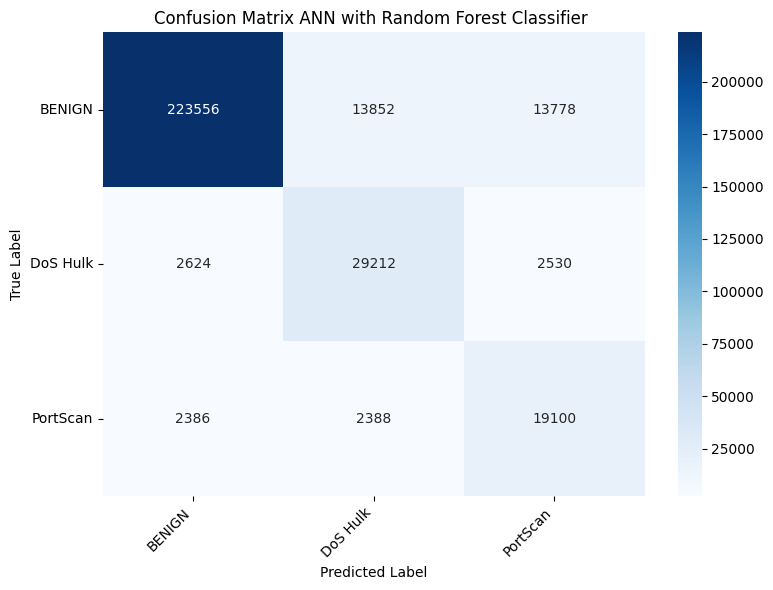

In [27]:
label_names = ['BENIGN', 'DoS Hulk', 'PortScan']

cm = confusion_matrix(y_test, ens_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('Confusion Matrix ANN with Random Forest Classifier ')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Model 2

GNN (GraphSAGE) for node classification on a kNN similarity graph

In [129]:
pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.6 MB/s eta 0:00:00


In [130]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

In [131]:
target_col = "Label_multi"
X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).copy()
y = df[target_col].astype(int).values

In [132]:
idx = np.arange(len(df))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)

X_train = X.iloc[idx_train].copy()
X_test  = X.iloc[idx_test].copy()
y_train = y[idx_train]
y_test  = y[idx_test]

In [133]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

In [134]:
X_all = np.vstack([X_train_sc, X_test_sc]).astype(np.float32)
y_all = np.concatenate([y_train, y_test]).astype(np.int64)

n_train = len(idx_train)
train_mask = torch.zeros(len(y_all), dtype=torch.bool)
test_mask  = torch.zeros(len(y_all), dtype=torch.bool)
train_mask[:n_train] = True
test_mask[n_train:]  = True

In [ ]:
k = 10
nn = NearestNeighbors(n_neighbors=k+1, metric="euclidean")
nn.fit(X_all)
nbrs = nn.kneighbors(X_all, return_distance=False)

In [ ]:
src = np.repeat(np.arange(len(X_all)), k)
dst = nbrs[:, 1:].reshape(-1)
edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long)


In [ ]:
data = Data(
    x=torch.tensor(X_all),
    edge_index=edge_index,
    y=torch.tensor(y_all),
    train_mask=train_mask,
    test_mask=test_mask
)

In [ ]:
class SAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SAGE(in_dim=data.num_features, hidden_dim=64, out_dim=int(np.max(y_all)+1)).to(device)
data = data.to(device)

opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

In [ ]:
# for epoch in range(1, 51):
#     model.train()
#     opt.zero_grad()
#     out = model(data.x, data.edge_index)
#     loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
#     loss.backward()
#     opt.step()

#     if epoch % 10 == 0:
#         model.eval()
#         pred = out.argmax(dim=1)
#         acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item()
#         print(f"Epoch {epoch:03d} | loss={loss.item():.4f} | test_acc={acc:.4f}")

In [ ]:
model.eval()
out = model(data.x, data.edge_index)

In [ ]:
y_true = data.y[data.test_mask].detach().cpu().numpy()
y_pred = out[data.test_mask].argmax(dim=1).detach().cpu().numpy()

In [31]:
print("\n=== Graph Neural Network ===")
label_names = ['BENIGN', 'DoS Hulk', 'PortScan']
print((classification_report(y_test, ens_test_pred,
                               target_names=label_names)))


=== Graph Neural Network ===
              precision    recall  f1-score   support

      BENIGN       0.99      0.97      0.98    251186
    DoS Hulk       0.88      0.95      0.91     34366
    PortScan       0.83      0.95      0.89     23874

    accuracy                           0.97    309426
   macro avg       0.90      0.96      0.93    309426
weighted avg       0.97      0.97      0.97    309426



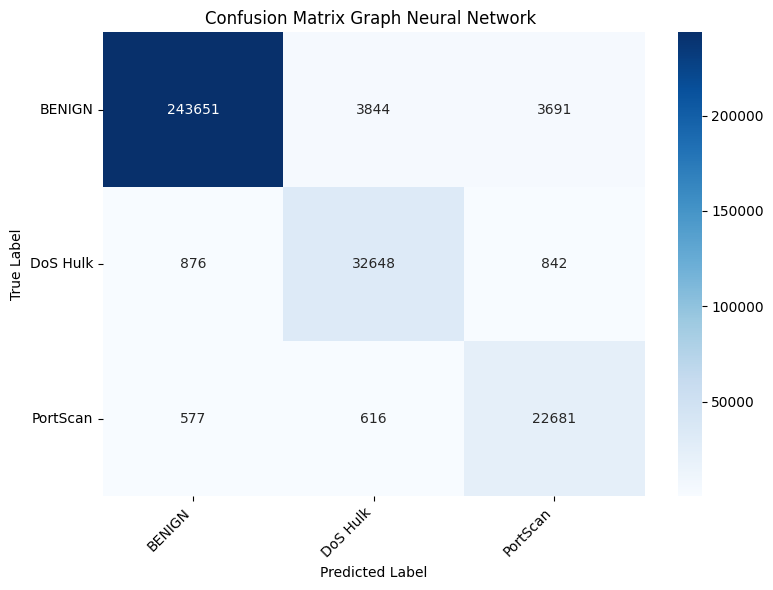

In [32]:
label_names = ['BENIGN', 'DoS Hulk', 'PortScan']

cm = confusion_matrix(y_test, ens_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('Confusion Matrix Graph Neural Network ')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Model 3 Logistic Regression

In [33]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

In [34]:
X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).copy()
y = df[target_col].astype(int).values

In [35]:
idx = np.arange(len(df))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)

X_train = X.iloc[idx_train].copy()
X_test  = X.iloc[idx_test].copy()
y_train = y[idx_train]
y_test  = y[idx_test]

In [36]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weights:", class_weight_dict)

Class weights: {0: 0.41108419161038234, 1: 2.9744116592138394, 2: 4.325122197324108}


In [38]:
lr = LogisticRegression(
    max_iter=100,
    solver="saga",
    multi_class="multinomial",
    class_weight=class_weight_dict,
    n_jobs=-1
)

lr.fit(X_train_sc, y_train)

y_pred = lr.predict(X_test_sc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [39]:
print("\n===Logistic Regression ===")
label_names = ['BENIGN', 'DoS Hulk', 'PortScan']
print((classification_report(y_test, y_pred,
                               target_names=label_names)))


===Logistic Regression ===
              precision    recall  f1-score   support

      BENIGN       1.00      0.96      0.98    334691
    DoS Hulk       0.81      0.99      0.89     46132
    PortScan       0.90      0.99      0.95     31745

    accuracy                           0.96    412568
   macro avg       0.90      0.98      0.94    412568
weighted avg       0.97      0.96      0.97    412568



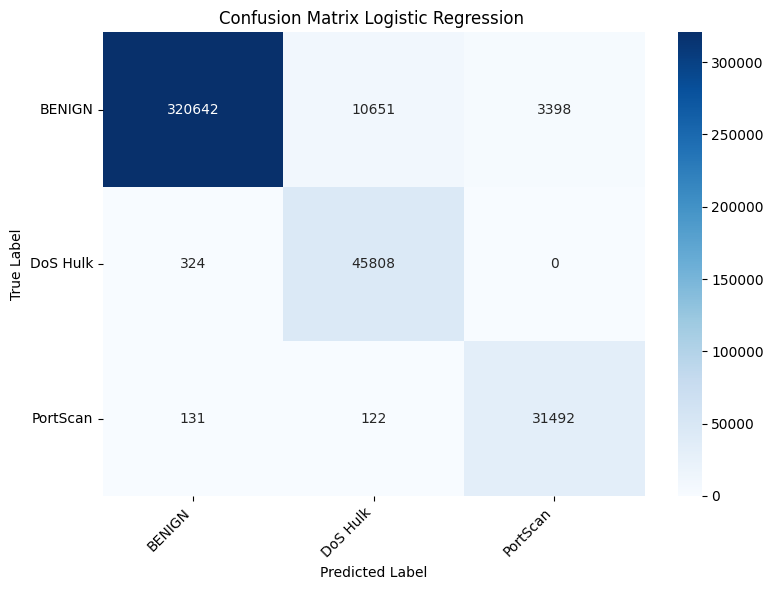

In [40]:
label_names = ['BENIGN', 'DoS Hulk', 'PortScan']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('Confusion Matrix Logistic Regression ')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()